# Decision Tree from Scratch (Pure Python)
CART algorithm with Gini impurity — no numpy in the core logic, no sklearn.
Dataset: Iris (4 features, 3 classes). Model saved to `../Models/dt_scratch.json`.

## 1. Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris        = load_iris()
df          = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target']= iris.target
features    = list(iris.feature_names)
class_names = list(iris.target_names)

print(f"Shape: {df.shape}  |  Classes: {class_names}")
df.head(3)

Shape: (150, 5)  |  Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


## 2. Train / Test Split (80/20, stratified)

In [4]:
X = df[features].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 120  |  Test: 30


## 3. Decision Tree Theory — CART

CART (Classification and Regression Trees) builds a binary tree by greedily choosing
the split that minimises **Gini impurity** at each node.

**Gini impurity** at node $t$ with $K$ classes:
$$G(t) = 1 - \sum_{k=1}^{K} p_k^2$$
where $p_k$ = fraction of samples in class $k$. Pure node → $G=0$. Worst case → $G=0.5$ (binary).

**Weighted Gini after split** on feature $j$ at threshold $\theta$:
$$G_{split} = \frac{n_L}{n} G(t_L) + \frac{n_R}{n} G(t_R)$$

**Algorithm (recursive):**
1. Find the $(j, \theta)$ pair that minimises $G_{split}$
2. Split data into left ($x_j \leq \theta$) and right ($x_j > \theta$)
3. Recurse on each side until a stopping criterion is met
4. At a leaf, predict the **majority class**

## 4. Node & Tree Implementation

In [5]:
class Node:
    __slots__ = ['feature', 'threshold', 'left', 'right', 'value', 'gini', 'n_samples', 'class_counts']

    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 value=None, gini=0.0, n_samples=0, class_counts=None):
        self.feature      = feature        # feature index to split on
        self.threshold    = threshold      # split value
        self.left         = left           # Node: samples where x[feature] <= threshold
        self.right        = right          # Node: samples where x[feature] >  threshold
        self.value        = value          # int: majority class (leaf nodes only)
        self.gini         = gini
        self.n_samples    = n_samples
        self.class_counts = class_counts or {}

    @property
    def is_leaf(self):
        return self.value is not None

In [6]:
def gini_impurity(y):
    """Gini = 1 - sum(p_k^2). Pure Python — no numpy."""
    n = len(y)
    if n == 0:
        return 0.0
    counts = Counter(y)
    return 1.0 - sum((c / n) ** 2 for c in counts.values())


def best_split(X, y, features_idx):
    """
    Exhaustive search over all features and all unique thresholds.
    Returns: (best_feature_idx, best_threshold, best_weighted_gini)
    """
    best_gini   = float('inf')
    best_feat   = None
    best_thresh = None
    n           = len(y)

    for feat in features_idx:
        col        = [X[i][feat] for i in range(n)]
        thresholds = sorted(set(col))[:-1]          # midpoints between unique values

        for thresh in thresholds:
            left_y  = [y[i] for i in range(n) if X[i][feat] <= thresh]
            right_y = [y[i] for i in range(n) if X[i][feat] >  thresh]

            if not left_y or not right_y:
                continue

            w_gini = (len(left_y)  * gini_impurity(left_y) +
                      len(right_y) * gini_impurity(right_y)) / n

            if w_gini < best_gini:
                best_gini   = w_gini
                best_feat   = feat
                best_thresh = thresh

    return best_feat, best_thresh, best_gini


def grow_tree(X, y, depth=0, max_depth=10, min_samples_split=2):
    n         = len(y)
    counts    = Counter(y)
    majority  = counts.most_common(1)[0][0]
    node_gini = gini_impurity(y)

    # ── Stopping criteria ──────────────────────────────────────────────────
    if depth >= max_depth or n < min_samples_split or len(counts) == 1:
        return Node(value=majority, gini=node_gini, n_samples=n, class_counts=dict(counts))

    feat, thresh, w_gini = best_split(X, y, range(len(X[0])))

    if feat is None:                                # no valid split found
        return Node(value=majority, gini=node_gini, n_samples=n, class_counts=dict(counts))

    left_mask  = [X[i][feat] <= thresh for i in range(n)]
    right_mask = [not m for m in left_mask]
    X_l = [X[i] for i in range(n) if left_mask[i]]
    y_l = [y[i] for i in range(n) if left_mask[i]]
    X_r = [X[i] for i in range(n) if right_mask[i]]
    y_r = [y[i] for i in range(n) if right_mask[i]]

    return Node(
        feature      = feat,
        threshold    = thresh,
        gini         = node_gini,
        n_samples    = n,
        class_counts = dict(counts),
        left         = grow_tree(X_l, y_l, depth+1, max_depth, min_samples_split),
        right        = grow_tree(X_r, y_r, depth+1, max_depth, min_samples_split)
    )


def predict_one(x, node):
    if node.is_leaf:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_one(x, node.left)
    return predict_one(x, node.right)


def predict(X, root):
    return [predict_one(x, root) for x in X]

## 5. Train

In [7]:
MAX_DEPTH = 4

X_train_list = X_train.tolist()
y_train_list = y_train.tolist()

tree = grow_tree(X_train_list, y_train_list, max_depth=MAX_DEPTH)
print(f"Tree grown  |  Root feature: {features[tree.feature]}  |  Threshold: {tree.threshold:.3f}")

Tree grown  |  Root feature: petal length (cm)  |  Threshold: 1.900


## 6. Text Tree Printer

In [8]:
def print_tree(node, feature_names, class_names, indent='', last=True):
    connector = '└── ' if last else '├── '
    if node.is_leaf:
        print(f"{indent}{connector}LEAF: {class_names[node.value]}  "
              f"(n={node.n_samples}, gini={node.gini:.3f})")
    else:
        print(f"{indent}{connector}[{feature_names[node.feature]} <= {node.threshold:.3f}]  "
              f"n={node.n_samples}, gini={node.gini:.3f}")
        child_indent = indent + ('    ' if last else '│   ')
        print_tree(node.left,  feature_names, class_names, child_indent, last=False)
        print_tree(node.right, feature_names, class_names, child_indent, last=True)

print_tree(tree, features, class_names)

└── [petal length (cm) <= 1.900]  n=120, gini=0.667
    ├── LEAF: setosa  (n=40, gini=0.000)
    └── [petal width (cm) <= 1.600]  n=80, gini=0.500
        ├── [petal length (cm) <= 4.900]  n=42, gini=0.133
        │   ├── LEAF: versicolor  (n=38, gini=0.000)
        │   └── [sepal length (cm) <= 6.000]  n=4, gini=0.375
        │       ├── LEAF: versicolor  (n=2, gini=0.500)
        │       └── LEAF: virginica  (n=2, gini=0.000)
        └── [petal length (cm) <= 4.800]  n=38, gini=0.051
            ├── [sepal width (cm) <= 2.800]  n=3, gini=0.444
            │   ├── LEAF: virginica  (n=2, gini=0.000)
            │   └── LEAF: versicolor  (n=1, gini=0.000)
            └── LEAF: virginica  (n=35, gini=0.000)


## 7. Evaluation

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_train = predict(X_train.tolist(), tree)
y_pred_test  = predict(X_test.tolist(),  tree)

print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test,  y_pred_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=class_names))

Train Accuracy: 0.9917
Test  Accuracy: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 8. Confusion Matrix

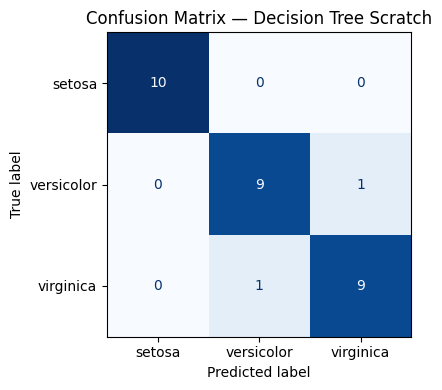

In [10]:
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Decision Tree Scratch')
plt.tight_layout(); plt.show()

## 9. Feature Importance (Split Count)

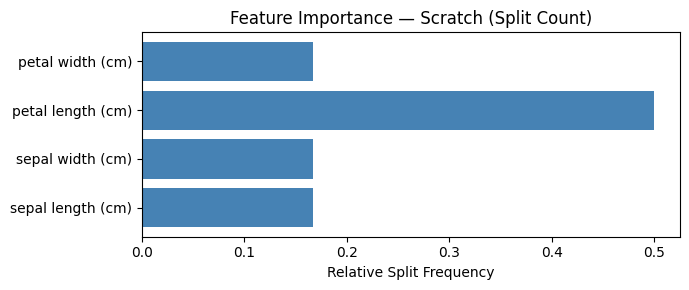

In [11]:
def count_splits(node, counts=None):
    if counts is None:
        counts = Counter()
    if not node.is_leaf:
        counts[node.feature] += 1
        count_splits(node.left,  counts)
        count_splits(node.right, counts)
    return counts

split_counts = count_splits(tree)
total        = sum(split_counts.values())
importances  = {features[k]: v/total for k, v in sorted(split_counts.items())}

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(importances.keys()), list(importances.values()), color='steelblue')
ax.set_xlabel('Relative Split Frequency')
ax.set_title('Feature Importance — Scratch (Split Count)')
plt.tight_layout(); plt.show()

## 10. Effect of max_depth on Accuracy

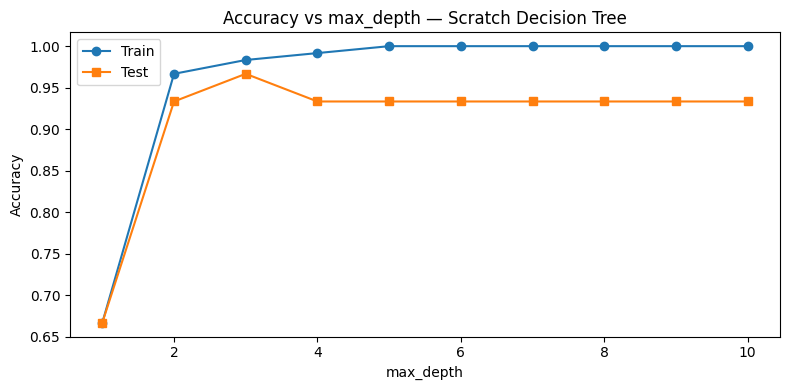

In [12]:
depths       = range(1, 11)
train_accs   = []
test_accs    = []

for d in depths:
    t = grow_tree(X_train_list, y_train_list, max_depth=d)
    train_accs.append(accuracy_score(y_train, predict(X_train.tolist(), t)))
    test_accs.append(accuracy_score(y_test,   predict(X_test.tolist(),  t)))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_accs, marker='o', label='Train')
plt.plot(depths, test_accs,  marker='s', label='Test')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Accuracy vs max_depth — Scratch Decision Tree')
plt.legend(); plt.tight_layout(); plt.show()

## 11. Save Model to `../Models`

In [13]:
def node_to_dict(node):
    if node.is_leaf:
        return {'leaf': True, 'value': int(node.value),
                'gini': node.gini, 'n_samples': node.n_samples,
                'class_counts': {str(k): v for k, v in node.class_counts.items()}}
    return {'leaf': False, 'feature': node.feature, 'threshold': node.threshold,
            'gini': node.gini, 'n_samples': node.n_samples,
            'class_counts': {str(k): v for k, v in node.class_counts.items()},
            'left': node_to_dict(node.left), 'right': node_to_dict(node.right)}


model_data = {
    'feature_names': features,
    'class_names':   class_names,
    'max_depth':     MAX_DEPTH,
    'split':         {'test_size': 0.2, 'random_state': 42, 'stratify': True},
    'tree':          node_to_dict(tree)
}
save_path = '../Models/dt_scratch.json'
with open(save_path, 'w') as f:
    json.dump(model_data, f)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/dt_scratch.json  (1.7 KB)
